In [13]:
import ecgformer
import plot_results
import ecgformer_training

Loading data/ecgmatformer_03-17-14:10_train.pickle …
Loading data/ecgmatformer_03-17-14:10_validation.pickle …
  epochs=199  granularities=[0, 1, 2, 3]


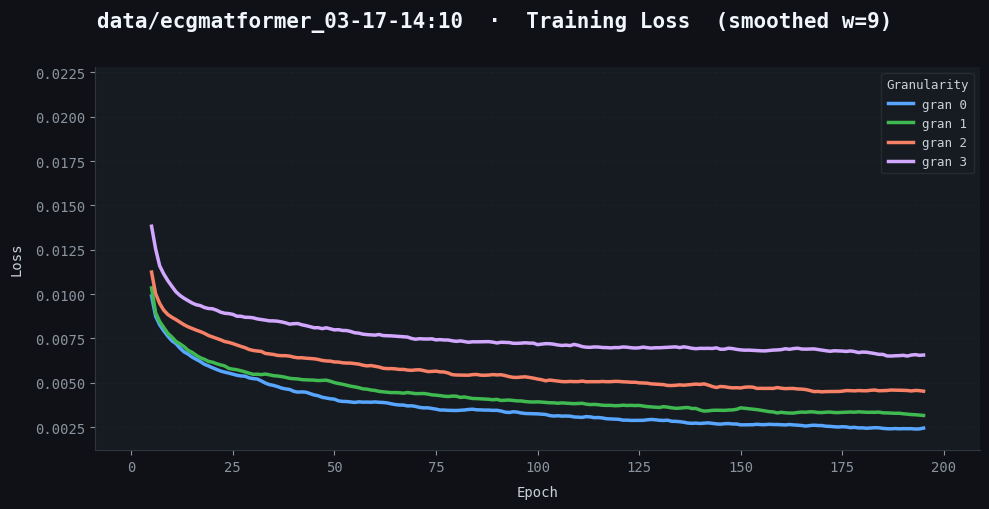

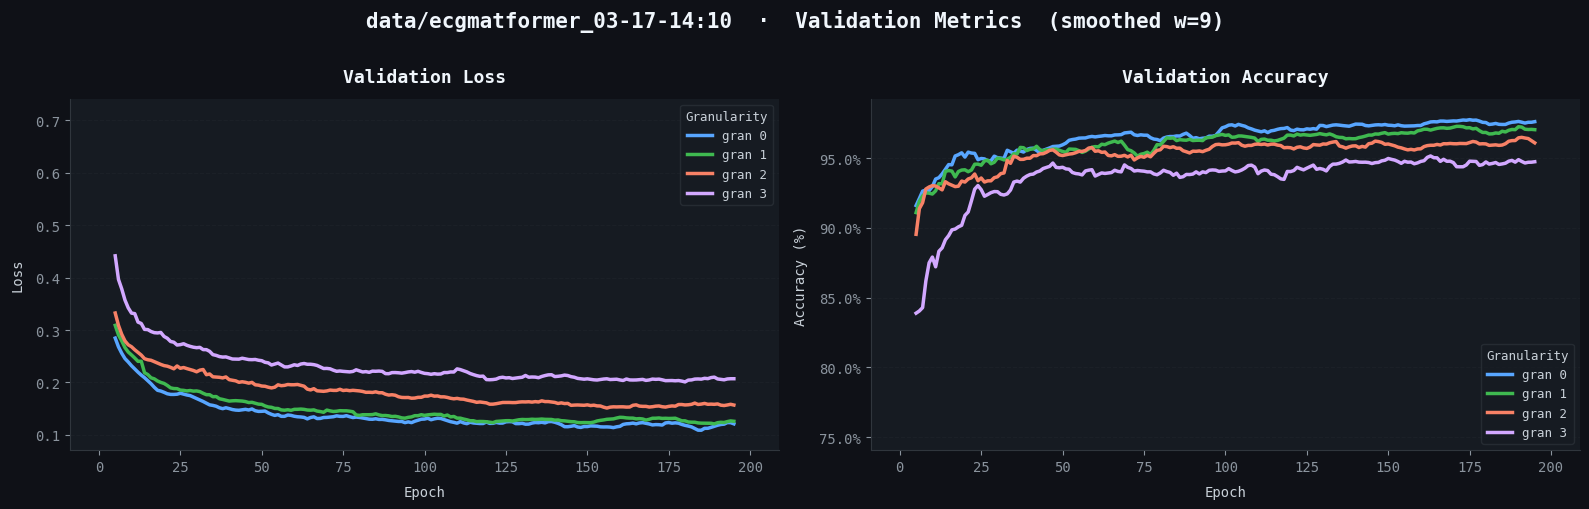

In [14]:
dir="data/"
filename="ecgmatformer_03-17-14:10"
plot_results.plot_results(dir+filename, True, 9)

Loaded data: X=(85243, 150)  y=(85243,)
Classes: ['N' 'O']
Loaded weights from data/ecgmatformer_03-17-14:10.pth

Matryoshka Granularity: 3
              precision    recall  f1-score   support

           N       0.98      0.96      0.97     14842
           O       0.77      0.89      0.83      2207

    accuracy                           0.95     17049
   macro avg       0.88      0.93      0.90     17049
weighted avg       0.96      0.95      0.95     17049


Matryoshka Granularity: 2
              precision    recall  f1-score   support

           N       0.99      0.97      0.98     14842
           O       0.81      0.92      0.86      2207

    accuracy                           0.96     17049
   macro avg       0.90      0.94      0.92     17049
weighted avg       0.96      0.96      0.96     17049


Matryoshka Granularity: 1
              precision    recall  f1-score   support

           N       0.99      0.97      0.98     14842
           O       0.81      0.95      0.88

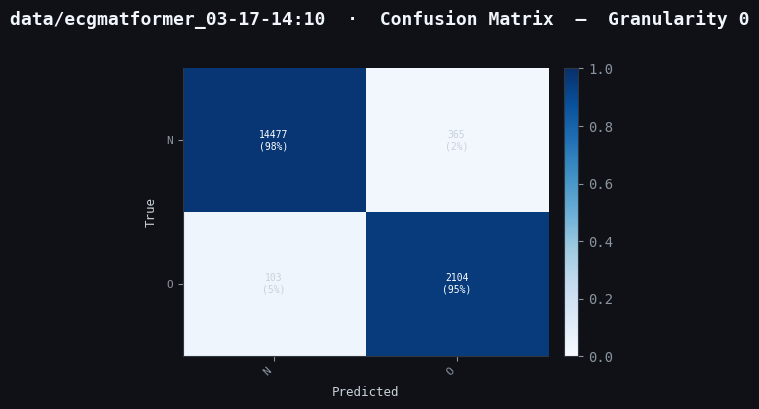

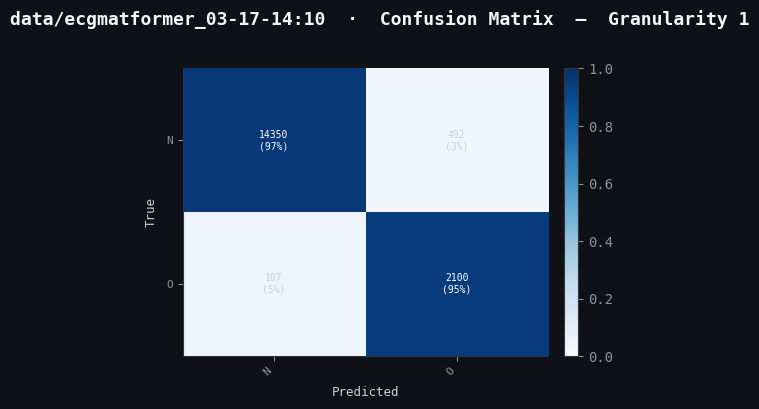

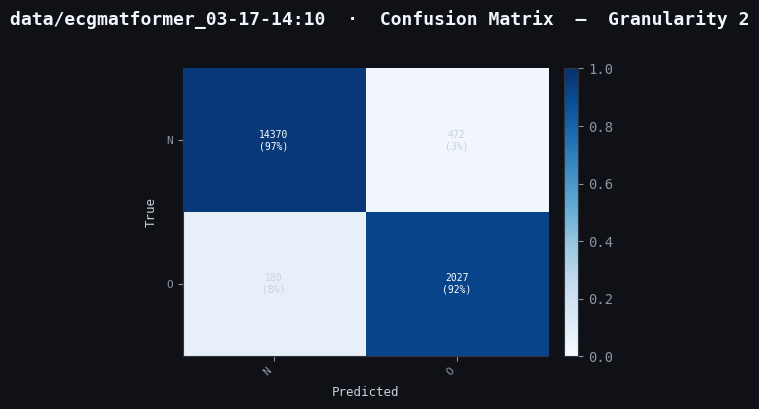

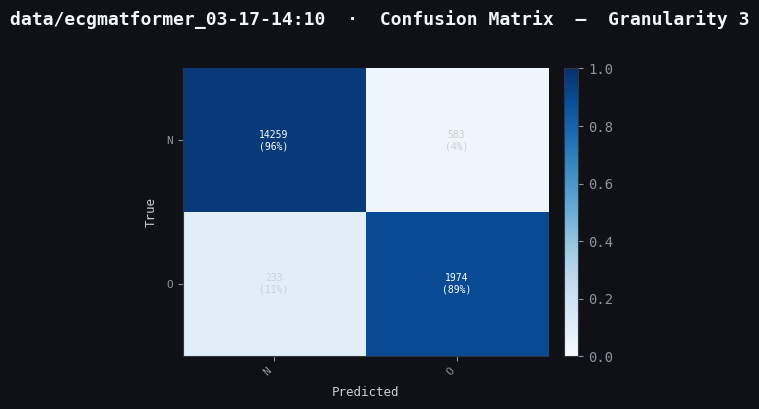

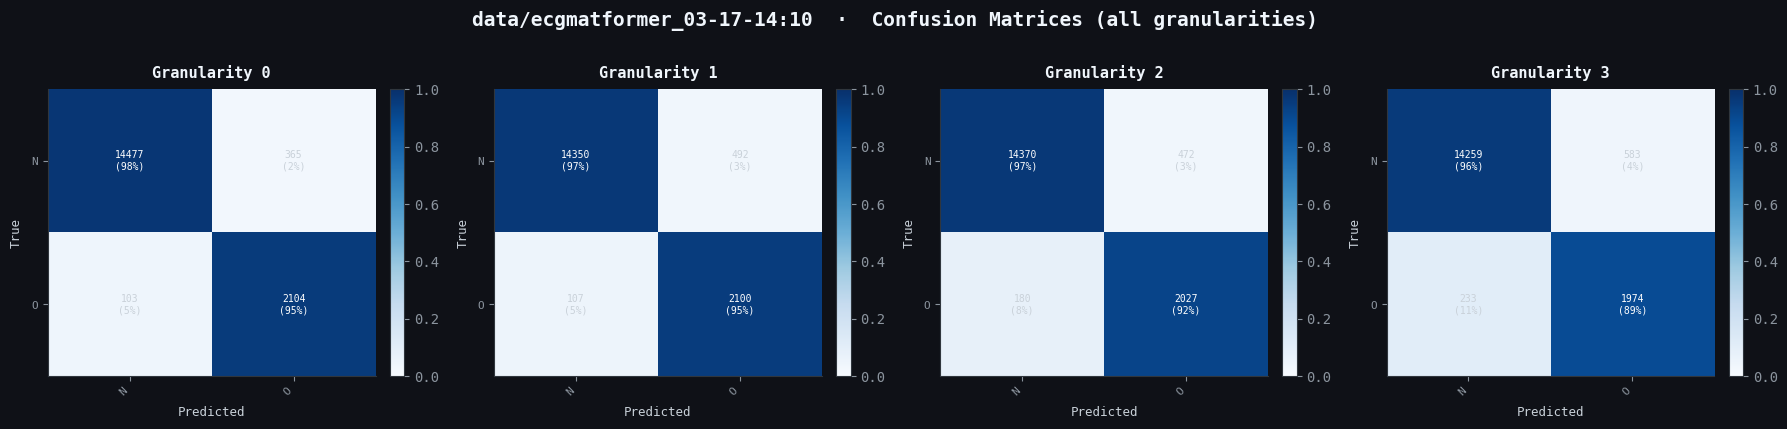

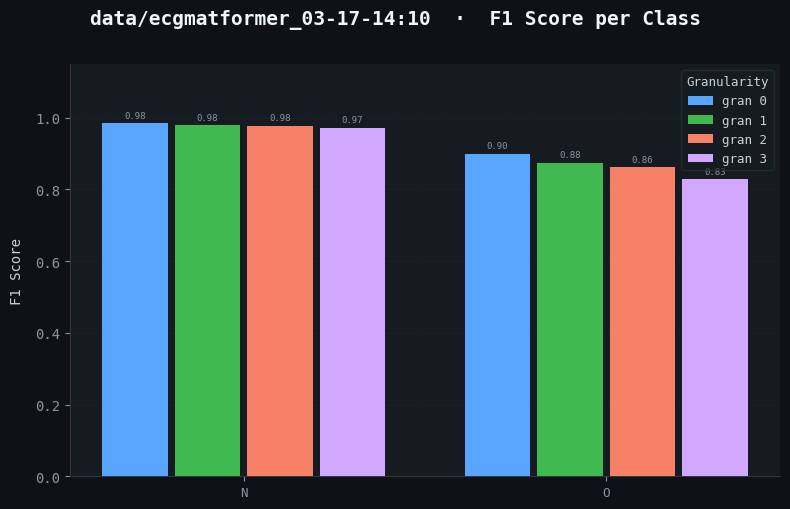

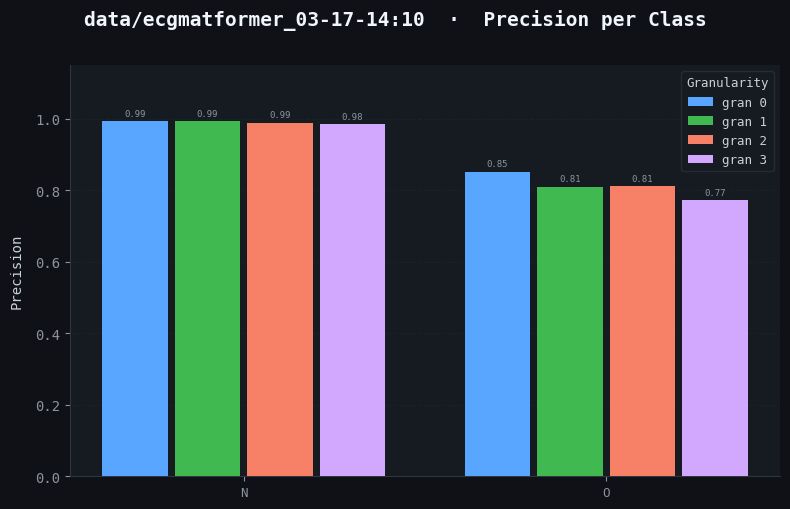

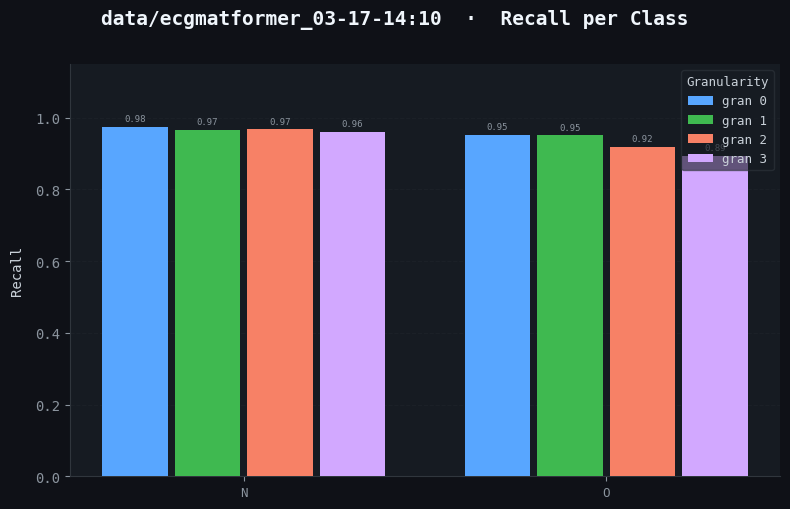

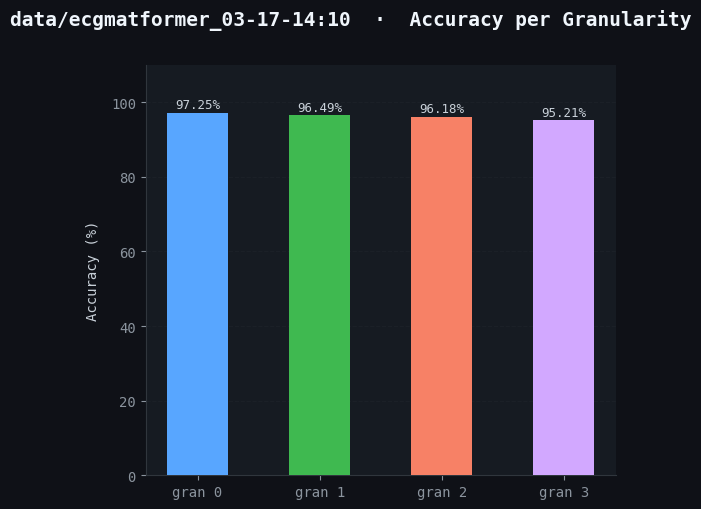

In [15]:
ecgformer_training.run_evaluation(dir+filename, None, None, True)

In [19]:
device="cuda"
params = dict(
    input_length    = 150,
    patch_size      = 10,
    d_model         = 128,
    num_heads       = 8,
    num_layers      = 4,
    d_ffn           = 128,
    dropout         = 0.15,
    num_classes     = 2,
    device          = device,
    matryoshka_depth= 4,
)
model = ecgformer.ECGMatformer(**params).to(device)
non_encoder_params_count = params['patch_size'] * params['d_model'] + params['d_model'] * params['d_model'] // 2 + params['d_model'] // 2 * params["num_classes"]
print(non_encoder_params_count)
single_encoder_params_count = params['d_model'] * params['d_model'] * 3 + params['d_model'] ** 2 + params['d_model'] * params['d_ffn'] + params['d_ffn'] * params['d_model']
print(single_encoder_params_count)
full_params_count = non_encoder_params_count + params['num_layers'] * single_encoder_params_count
print(full_params_count)
def mat_combinations(depth, num_layers):
    combinations = []
    for i in range(num_layers):
        added = []
        for j in range(depth):
            if len(combinations) == 0:
                added.append([j])
            else:
                for comb in combinations:
                    if j == comb[-1] or j - comb[-1] == 1:
                        added.append(comb.append(j))
        combinations = added
    return combinations
print(mat_combinations(params['matryoshka_depth'], params['num_layers']))

9600
98304
402816


TypeError: 'NoneType' object is not subscriptable